In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### DataFrames

In [38]:
df_1 = pd.read_csv('data\ogd-smn_bou_t_historical_2000-2009.csv', sep=';')
df_2 = pd.read_csv('data\ogd-smn_bou_t_historical_2010-2019.csv', sep=';')
df_3 = pd.read_csv('data\ogd-smn_bou_t_historical_2020-2029.csv', sep=';')

In [40]:
frames = [df_1, df_2, df_3]
df = pd.concat(frames, ignore_index=True)

### Suppression des colonnes ayant plus de 90% de NaN

  station_abbr reference_timestamp  tre200s0  xchills0  ure200s0  tde200s0  \
0          BOU    01.02.2004 00:00       NaN       NaN       NaN       NaN   
1          BOU    01.02.2004 00:10       NaN       NaN       NaN       NaN   
2          BOU    01.02.2004 00:20       NaN       NaN       NaN       NaN   
3          BOU    01.02.2004 00:30       NaN       NaN       NaN       NaN   
4          BOU    01.02.2004 00:40       NaN       NaN       NaN       NaN   

   pva200s0  prestas0  pp0qnhs0  pp0qffs0  fkl010z1  fve010z0  fkl010z0  \
0       NaN       NaN       NaN       NaN       2.8       1.9       1.9   
1       NaN       NaN       NaN       NaN       3.0       2.2       2.3   
2       NaN       NaN       NaN       NaN       4.0       2.4       2.5   
3       NaN       NaN       NaN       NaN       5.2       3.7       3.8   
4       NaN       NaN       NaN       NaN       4.7       3.2       3.3   

   dkl010z0  fu3010z0  fkl010z3  fu3010z1  fu3010z3  rre150z0  
0     149.0     

<Axes: >

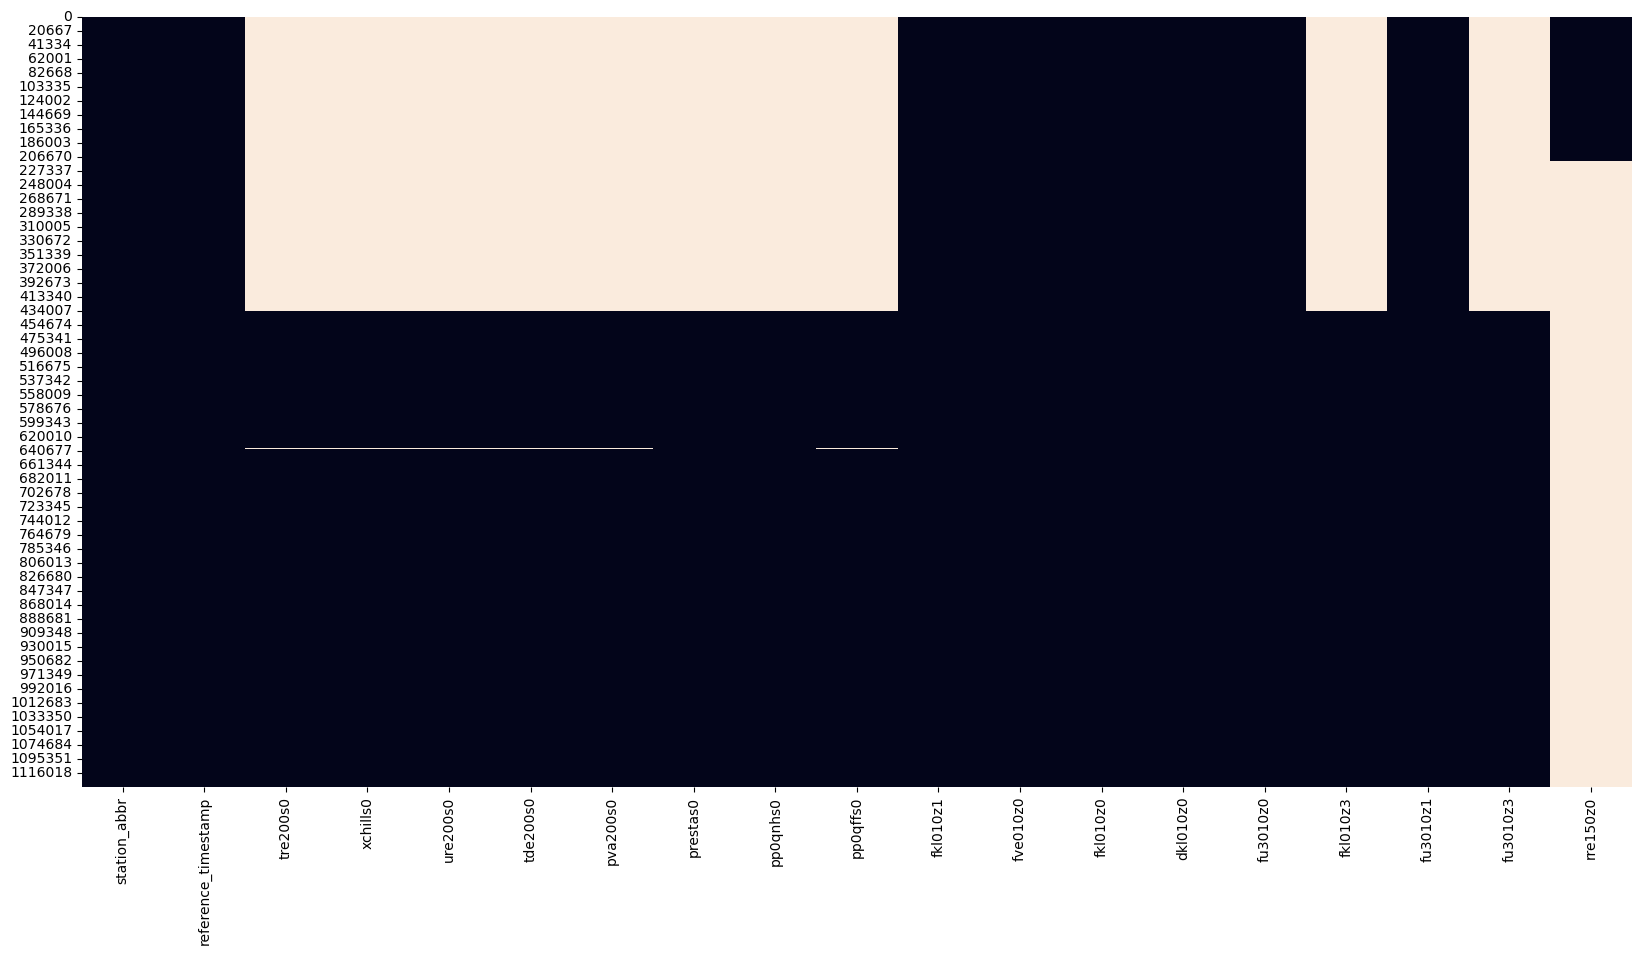

In [45]:
df = df[df.columns[df.isna().sum()/df.shape[0] <0.9]]
print(df.head())

plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)

### Renommage des colonnes

In [67]:
nouveau_noms_colonnes = {
    "station_abbr": "abr_station",  # station_abbreviation
    "reference_timestamp": "horodatage_référence",  # reference_timestamp
    "tre200s0": "température_air",  # Air temperature 2 m above ground; current value [cite: 1]
    "xchills0": "température_refroidissement_éolien",  # Chill temperature; current value [cite: 141]
    "ure200s0": "humidité",  # Relative air humidity 2 m above ground; current value [cite: 5, 6]
    "tde200s0": "point_de_rosée",  # Dew point 2 m above ground; current value [cite: 17]
    "pva200s0": "pression_vapeur",  # Vapour pressure 2 m above ground; current value [cite: 175, 176]
    "prestas0": "pression_barométrique_qfe",  # Atmospheric pressure at barometric altitude (QFE); current value [cite: 1]
    "pp0qnhs0": "pression_niveau_mer_standard_qnh",  # Atmospheric pressure reduced to sea level according to standard atmosphere (QNH); current value [cite: 168]
    "pp0qffs0": "pression_niveau_mer_réelle_qff",  # Atmospheric pressure reduced to sea level (QFF); current value [cite: 170]
    "fkl010z1": "rafale_1s_maximum_10min",  # Gust peak (one second); maximum in m/s [cite: 7]
    "fve010z0": "vitesse_vent_vectorielle_moyenne_10min",  # Wind speed vectoriel; ten minutes mean in m/s [cite: 18, 19]
    "fkl010z0": "vitesse_vent_scalaire_moyenne_10min",  # Wind speed scalar; ten minutes mean in m/s [cite: 21]
    "dkl010z0": "direction_du_vent_moyenne_10min",  # Wind direction; ten minutes mean [cite: 22]
    "fu3010z0": "vitesse_vent_moyenne_10min_kmh",  # Wind speed; ten minutes mean in km/h [cite: 191]
    "fkl010z3": "rafale_3s_maximum_10min",  # Gust peak (three seconds); maximum in m/s [cite: 216]
    "fu3010z1": "rafale_1s_maximum_kmh",  # Gust peak (one second); maximum in km/h [cite: 219]
    "fu3010z3": "rafale_3s_maximum_kmh",  # Gust peak (three seconds); maximum in km/h [cite: 239]
    "rre150z0": "précipitations",  # Precipitation; ten minutes total [cite: 3]
}

df.rename(columns=nouveau_noms_colonnes, inplace=True) # ? remplacement des anciens titres de colonne par des nouveaux

### Transformation du .csv en .parquet

In [70]:
df.to_parquet('data/processed_windspeed.parquet', engine='pyarrow', index=False)